Processed 'Test1_WIFI_Direct_Rayban_insta-glass.csv' and created 'g2p_android_wifi_direct_cdf.csv'
Processed 'Test1_WIFI_Direct_Rayban_insta.csv' and created 'p2s_android_wifi_direct_cdf.csv'
Processed 'Test1-insta-WS-IOS-RB.csv' and created 'p2s_android_ws_cdf.csv'
Processed 'p2s_IOS_cdf_data_3MB.csv' and created 'p2s_ios_3mb_cdf.csv'
Processed IOS_bitrate_cdf_combined_receive.csv: Median Bitrate (at 0.6 CDF) = 1.02 Mbps
Processed average_g2p_bitrate_cdf.csv: Median Bitrate (at 0.6 CDF) = 0.81 Mbps
Processed g2p_android_wifi_direct_cdf.csv: Median Bitrate (at 0.6 CDF) = 1.11 Mbps
Processed p2s_ios_3mb_cdf.csv: Median Bitrate (at 0.6 CDF) = 3.80 Mbps
Processed p2s_android_ws_cdf.csv: Median Bitrate (at 0.6 CDF) = 3.53 Mbps
Processed p2s_android_wifi_direct_cdf.csv: Median Bitrate (at 0.6 CDF) = 3.44 Mbps


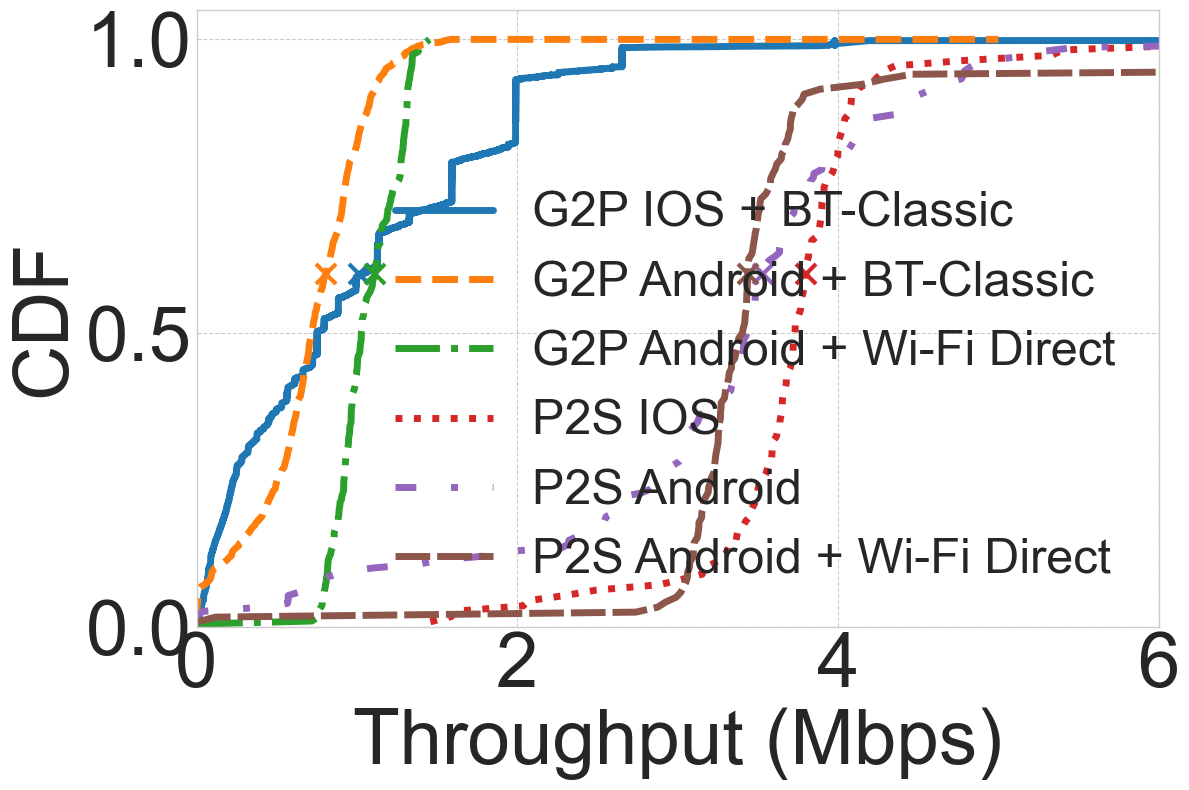

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import os

def plot_cdfs(file_info_list):
    """
    Plots the CDFs from a list of CSV files with unique line styles and marks the median point.
    """
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(12, 8))

    # --- Define styles and fonts ---
    universal_font_size = 55
    # Define a list of line styles to cycle through for each plot
    line_styles = ['-', '--', '-.', ':', (0, (3, 5, 1, 5)), (0, (5, 1))]

    # Use enumerate to get an index 'i' for each file
    for i, file_info in enumerate(file_info_list):
        try:
            # Read the CSV file into a pandas DataFrame
            df = pd.read_csv(file_info['filename'])

            # Clean up column names by stripping whitespace
            df.columns = [col.strip() for col in df.columns]

            bitrate_col = file_info['bitrate_col']
            cdf_col = file_info['cdf_col']

            # Ensure the necessary columns exist
            if bitrate_col not in df.columns or cdf_col not in df.columns:
                print(f"Warning: Skipping {file_info['filename']}. Required columns not found.")
                print(f"Available columns: {df.columns.tolist()}")
                continue

            # Convert bitrate to Mbps if necessary
            if file_info['unit'] == 'bps':
                df[bitrate_col] = df[bitrate_col] / 1_000_000.0

            # --- Data Cleaning: Remove NaNs and Infs, and sort ---
            df.replace([np.inf, -np.inf], np.nan, inplace=True)
            df.dropna(subset=[bitrate_col, cdf_col], inplace=True)
            df = df.sort_values(by=bitrate_col)

            if df.empty:
                print(f"Warning: Skipping {file_info['filename']} after cleaning. No data left.")
                continue

            x_data = df[bitrate_col]
            y_data = df[cdf_col]

            # Plot the CDF using a unique line style from the list
            line, = ax.plot(x_data, y_data,
                            label=file_info['label'],
                            linewidth=5,
                            linestyle=line_styles[i % len(line_styles)]) # Cycle through styles

            # --- Calculate and plot the median (0.6 CDF) point ---
            target_cdf = 0.6
            median_bitrate = np.interp(target_cdf, y_data, x_data)

            # Add a distinct marker for the median point
            ax.plot(median_bitrate, target_cdf, 'x', color=line.get_color(),
                    markersize=15, markeredgewidth=3)

            print(f"Processed {file_info['filename']}: Median Bitrate (at {target_cdf} CDF) = {median_bitrate:.2f} Mbps")

        except FileNotFoundError:
            print(f"Error: The file {file_info['filename']} was not found.")
        except Exception as e:
            print(f"An error occurred while processing {file_info['filename']}: {e}")

    # --- Final Plot Configuration with Uniform Font Size ---
    ax.set_xlabel('Throughput (Mbps)', fontsize=universal_font_size)
    ax.set_ylabel('CDF', fontsize=universal_font_size)
    ax.tick_params(axis='both', which='major', labelsize=universal_font_size)
    ax.legend(fontsize=35)

    ax.set_ylim(0, 1.05)
    ax.set_xlim(0, 6)
    ax.grid(True, which="both", ls="--")

    plt.tight_layout()
    # Ensure the 'Figures' directory exists
    if not os.path.exists('Figures'):
        os.makedirs('Figures')
    plt.savefig('../../../Plots/CDF_Throughput_RB.png')
    plt.show()

if __name__ == '__main__':
    try:
        # G2P processing
        df_g2p = pd.read_csv('Test1_WIFI_Direct_Rayban_insta-glass.csv')
        df_g2p_sorted = df_g2p.sort_values(by='Filtered packets')
        df_g2p_sorted['CDF'] = np.arange(1, len(df_g2p_sorted) + 1) / len(df_g2p_sorted)
        df_g2p_sorted.rename(columns={'Filtered packets': 'Bitrate_bps'}, inplace=True)
        df_g2p_sorted.to_csv('g2p_android_wifi_direct_cdf.csv', index=False)
        print("Processed 'Test1_WIFI_Direct_Rayban_insta-glass.csv' and created 'g2p_android_wifi_direct_cdf.csv'")

        # P2S processing
        df_p2s = pd.read_csv('Test1_WIFI_Direct_Rayban_insta.csv')
        df_p2s_sorted = df_p2s.sort_values(by='Filtered packets')
        df_p2s_sorted['CDF'] = np.arange(1, len(df_p2s_sorted) + 1) / len(df_p2s_sorted)
        df_p2s_sorted.rename(columns={'Filtered packets': 'Bitrate_bps'}, inplace=True)
        df_p2s_sorted.to_csv('p2s_android_wifi_direct_cdf.csv', index=False)
        print("Processed 'Test1_WIFI_Direct_Rayban_insta.csv' and created 'p2s_android_wifi_direct_cdf.csv'")

        # P2S Android processing from the new CSV file
        df_p2s_android = pd.read_csv('Test1-insta-WS-IOS-RB.csv')
        df_p2s_android_sorted = df_p2s_android.sort_values(by='Filtered packets')
        df_p2s_android_sorted['CDF'] = np.arange(1, len(df_p2s_android_sorted) + 1) / len(df_p2s_android_sorted)
        df_p2s_android_sorted.rename(columns={'Filtered packets': 'Bitrate_bps'}, inplace=True)
        df_p2s_android_sorted.to_csv('p2s_android_ws_cdf.csv', index=False)
        print("Processed 'Test1-insta-WS-IOS-RB.csv' and created 'p2s_android_ws_cdf.csv'")

        # *** NEW: P2S IOS (3MB) processing ***
        df_p2s_ios_new = pd.read_csv('p2s_IOS_cdf_data_3MB.csv')
        df_p2s_ios_new.columns = [col.strip() for col in df_p2s_ios_new.columns] # Clean column names
        df_p2s_ios_new_sorted = df_p2s_ios_new.sort_values(by='All Packets')
        df_p2s_ios_new_sorted['CDF'] = np.arange(1, len(df_p2s_ios_new_sorted) + 1) / len(df_p2s_ios_new_sorted)
        df_p2s_ios_new_sorted.rename(columns={'All Packets': 'Bitrate_bps'}, inplace=True)
        df_p2s_ios_new_sorted.to_csv('p2s_ios_3mb_cdf.csv', index=False)
        print("Processed 'p2s_IOS_cdf_data_3MB.csv' and created 'p2s_ios_3mb_cdf.csv'")


    except FileNotFoundError as e:
        print(f"Error during preprocessing: {e}. Make sure the new files are in the directory.")
    except Exception as e:
        print(f"An error occurred during preprocessing: {e}")


    # --- Step 2: Define the list of all files to plot ---
    files_to_plot = [
        # --- Original Files ---
        {
            'filename': 'IOS_bitrate_cdf_combined_receive.csv',
            'label': 'G2P IOS + BT-Classic',
            'bitrate_col': 'Bitrate_bps',
            'cdf_col': 'CDF',
            'unit': 'bps'
        },
        {
            'filename': 'average_g2p_bitrate_cdf.csv',
            'label': 'G2P Android + BT-Classic',
            'bitrate_col': 'Bitrate_bps',
            'cdf_col': 'Average_CDF',
            'unit': 'bps'
        },
        {
            'filename': 'g2p_android_wifi_direct_cdf.csv',
            'label': 'G2P Android + Wi-Fi Direct',
            'bitrate_col': 'Bitrate_bps',
            'cdf_col': 'CDF',
            'unit': 'bps'
        },
        {
            'filename': 'p2s_ios_3mb_cdf.csv',
            'label': 'P2S IOS',
            'bitrate_col': 'Bitrate_bps',
            'cdf_col': 'CDF',
            'unit': 'bps'
        },
        {
            'filename': 'p2s_android_ws_cdf.csv',
            'label': 'P2S Android',
            'bitrate_col': 'Bitrate_bps',
            'cdf_col': 'CDF',
            'unit': 'bps'
        },
        {
            'filename': 'p2s_android_wifi_direct_cdf.csv',
            'label': 'P2S Android + Wi-Fi Direct',
            'bitrate_col': 'Bitrate_bps',
            'cdf_col': 'CDF',
            'unit': 'bps'
        }
    ]

    # --- Step 3: Plot all the CDFs ---
    plot_cdfs(files_to_plot)